In [2]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd
import matplotlib.patches as pat

In [3]:
QKE = pd.make_data_dictionary("../results/anvil/72-QKE_32_1_coh8.csv", "../results/anvil/51-full_QKE-eps.csv")
coherent = pd.make_data_dictionary("../results/coherent_only_run.csv", "../results/coherent_only_eps.csv")
thermal = pd.make_data_dictionary("../results/anvil/07-nu_nu_coll.csv", "../results/anvil/06-nu_e_coll-eps.csv")
match = pd.make_data_dictionary("../results/anvil/70-QKE_16match.csv", "../results/anvil/51-full_QKE-eps.csv")
dm4 = pd.make_data_dictionary("../results/anvil/76-QKE_32_4.csv", "../results/anvil/76-QKE_32_4-eps.csv")

In [4]:
e_color = '#008185'
m_color = '#5CBE00'
index_plots = [15, 45]

Figure 2

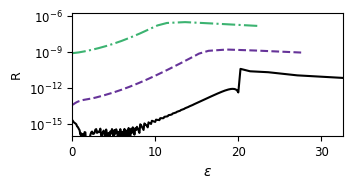

In [6]:
e10 = np.loadtxt("R_values-201-10-5.csv", delimiter=',')
e15 = np.loadtxt("R_values-201-15-5.csv", delimiter=',')
e20 = np.loadtxt("R_values-201-20-5.csv", delimiter=',')

plt.figure(figsize=(3.5,1.6))
plt.semilogy(e20[1][1:], e20[0][1:], c='k')
plt.semilogy(e15[1][1:], e15[0][1:], c='rebeccapurple', ls='--')
plt.semilogy(e10[1][1:], e10[0][1:], c='mediumseagreen', ls='-.')

plt.xlabel(r"$\epsilon$", fontsize=10)
plt.ylabel("R", fontsize=9)

plt.xlim(0, np.max(e20[1]))
plt.ylim(1e-16, 2e-6)

plt.yticks([1e-15, 1e-12, 1e-9, 1e-6], fontsize=8.5)
plt.xticks(fontsize=8.5)
plt.savefig("PaperFigs/R.pdf", bbox_inches='tight')

Figure 3

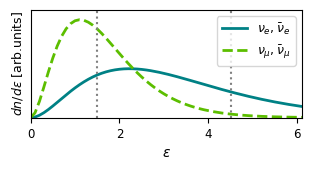

In [8]:
eps_max = 6.1

plt.figure(figsize=(3.5, 1.4))
eps = QKE['eps']
fe = QKE['dnde'][pd.NU_E]
fm = QKE['dnde'][pd.NU_MU]
plt.plot(eps, fe[0,:], c=e_color, lw=2, label=r"$\nu_e, \bar\nu_e$")
plt.plot(eps, fm[0,:], c=m_color, lw=2, ls="--", label=r"$\nu_\mu, \bar\nu_\mu$")
plt.xlim(0, eps_max)
plt.ylim(0, max(np.max(fe[0,:]), np.max(fm[0,:]))*1.1)
plt.legend(loc='upper right', fontsize=9)

plt.xlabel(r"$\epsilon$", fontsize=10)
plt.ylabel(r"$dn/d\epsilon$ [arb.units]", fontsize=9)

plt.axvline(eps[index_plots[0]], c='0.50', ls=":")
plt.axvline(eps[index_plots[1]], c='0.50', ls=":")

plt.yticks([])
plt.xticks([0,2,4,6], fontsize=8.5)
plt.savefig("PaperFigs/coherent-initial_cond.pdf", bbox_inches='tight')

In [9]:
fe = coherent['dnde'][pd.NU_E]
fm = coherent['dnde'][pd.NU_MU]
print(np.where(fm[:1000,15] > 0.99 * np.max(fm[:,15]))[0])
np.mean(coherent['time'][248:267])

maxmin = [np.min(fe[:,45]), np.max(fe[:,45]), np.min(fe[:,15]), np.max(fe[:,15])]
#ABCDE = [0, 22]
ABCDE = [0, 22]

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140
 141 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264
 265 266 373 374 375 376 377 378 379 380 381 382 383 384 385 386 387 388
 389 390 497 498 499 500 501 502 503 504 505 506 507 508 509 510 511 512
 513 514 621 622 623 624 625 626 627 628 629 630 631 632 633 634 635 636
 637 638 745 746 747 748 749 750 751 752 753 754 755 756 757 758 759 760
 761 762 869 870 871 872 873 874 875 876 877 878 879 880 881 882 883 884
 885 886 993 994 995 996 997 998 999]


In [10]:
print(np.where(fe[:1000,15] > 0.99 * np.max(fe[:,15]))[0])

[ 45  46  47  48  49  50  51  52  87  88  89  90  91  92  93  94 169 170
 171 172 173 174 175 176 212 213 214 215 216 217 218 294 295 296 297 298
 299 300 336 337 338 339 340 341 342 418 419 420 421 422 423 424 460 461
 462 463 464 465 466 542 543 544 545 546 547 548 584 585 586 587 588 589
 590 666 667 668 669 670 671 672 708 709 710 711 712 713 714 790 791 792
 793 794 795 796 832 833 834 835 836 837 838 914 915 916 917 918 919 920
 956 957 958 959 960 961 962]


In [11]:
ABCDE+=[np.argmax(fe[45:52,15])+45, np.argmin(fe[52:87,15])+52, np.argmax(fe[87:93,15])+87]

In [12]:
ABCDE.append(np.argmin((fe[22,15]-fe[93:123,15])**2)+93)
ABCDE.append(np.argmin(fe[123:141,15])+123)

In [13]:
ABCDE.append(np.argmin((fe[22,15]-fe[141:169,15])**2)+141)

In [14]:
ABCDE+=[np.argmax(fe[169:176,15])+169, np.argmin(fe[176:211,15])+176, np.argmax(fe[212:218,15])+212]

In [15]:
ABCDE.append(np.argmin((fe[22,15]-fe[218:248,15])**2)+218)
ABCDE.append(np.argmin(fe[248:266,15])+248)

In [16]:
ABCDE

[0, 22, 48, 70, 90, 117, 131, 147, 172, 194, 215, 242, 257]

Figure 4

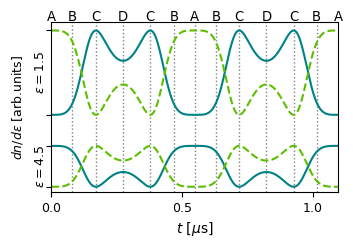

In [18]:
plt.figure(figsize=(3.7, 2.2))
#plt.plot(eps, fe[0,:], c=e_color, lw=2, label=r"$\nu_e, \bar\nu_e$")
#plt.plot(eps, fm[0,:], c=m_color, lw=2, ls="--", label=r"$\nu_\mu, \bar\nu_\mu$")
#plt.xlim(0, eps_max)
#plt.ylim(0, max(np.max(fe[0,:]), np.max(fm[0,:]))*1.1)
#plt.legend(fontsize=10)

for i in range(1, len(ABCDE)-1):
    plt.axvline(coherent['time'][ABCDE[i]], c='0.50', ls=':', lw=1)

plt.plot(coherent['time'], fe[:,15], color=e_color)
plt.plot(coherent['time'], fm[:,15], color=m_color, ls='--')

plt.plot(coherent['time'], fe[:,45], color=e_color)
plt.plot(coherent['time'], fm[:,45], color=m_color, ls='--')

plt.xlim(0, 1.096)
plt.ylim(0.25*maxmin[0], 1.05*maxmin[-1])
plt.xlabel(r"$t~[\mu{\rm s}]$", fontsize=10)
plt.ylabel(r"$dn/d\epsilon$ [arb.units]", fontsize=9, labelpad=12)

ABCDE_label = ["A", "B", "C", "D", "C", "B"]

for j, i in enumerate(ABCDE):
    plt.text(coherent['time'][i], 1.06*maxmin[-1], ABCDE_label[j%6], ha='center', fontsize=9.5)

plt.yticks(maxmin, ["","","",""])
plt.xticks([0, 0.5, 1.0], fontsize=9)

plt.text(-0.015, (maxmin[2]+maxmin[3])/2, r"$\epsilon = 1.5$", fontsize=9, rotation='vertical', va='center', ha='right')
plt.text(-0.015, (maxmin[0]+maxmin[1])/2, r"$\epsilon = 4.5$", fontsize=9, rotation='vertical', va='center', ha='right')

plt.savefig("PaperFigs/coherent-sync.pdf", bbox_inches='tight')

Figure 5

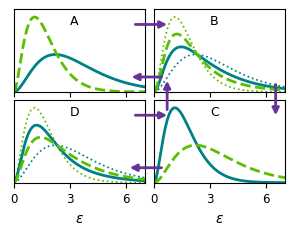

In [20]:
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(3.5, 2.25))
plt.subplots_adjust(hspace=0.1, wspace=0.1*2.5/3.5)

ax[0][0].set_xlim(0,7)
ax[0][0].set_ylim(0, max(np.max(fe[0,:]), np.max(fm[0,:]))*1.1)

ax[0][0].set_yticks([])

ax[0][1].plot(eps, fe[0,:], c=e_color, ls=':', lw=1.25)
ax[0][1].plot(eps, fm[0,:], c=m_color, ls=':', lw=1.25)
ax[1][0].plot(eps, fe[0,:], c=e_color, ls=':', lw=1.25)
ax[1][0].plot(eps, fm[0,:], c=m_color, ls=':', lw=1.25)

ax[0][0].plot(eps, fe[ABCDE[0],:], c=e_color, lw=2)
ax[0][0].plot(eps, fm[ABCDE[0],:], c=m_color, ls='--', lw=2)
ax[0][0].text(3, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "A", fontsize=9)

ax[0][1].plot(eps, fe[ABCDE[1]+5,:], c=e_color, lw=2)
ax[0][1].plot(eps, fm[ABCDE[1]+5,:], c=m_color, ls='--', lw=2)
ax[0][1].text(3, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "B", fontsize=9)

ax[1][1].plot(eps, fe[ABCDE[2],:], c=e_color, lw=2)
ax[1][1].plot(eps, fm[ABCDE[2],:], c=m_color, ls='--', lw=2)
ax[1][1].text(3, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "C", fontsize=9)

ax[1][0].plot(eps, fe[ABCDE[3],:], c=e_color, lw=2)
ax[1][0].plot(eps, fm[ABCDE[3],:], c=m_color, ls='--', lw=2)
ax[1][0].text(3, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "D", fontsize=9)

AB = pat.ConnectionPatch(
    xyA = (6.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (0.7, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[0][0], axesB = ax[0][1],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)
BC = pat.ConnectionPatch(
    xyA = (6.5, 0.1*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (6.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[0][1], axesB = ax[1][1],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)
CD = pat.ConnectionPatch(
    xyA = (0.4, 0.2*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (6.2, 0.2*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[1][1], axesB = ax[1][0],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)

DC = pat.ConnectionPatch(
    xyA = (6.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (0.7, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[1][0], axesB = ax[1][1],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)

CB = pat.ConnectionPatch(
    xyA = (0.7, 0.975*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (0.7, 0.15*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[1][1], axesB = ax[0][1],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)

BA = pat.ConnectionPatch(
    xyA = (0.4, 0.2*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (6.3, 0.2*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[0][1], axesB = ax[0][0],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)

fig.add_artist(AB)
fig.add_artist(BC)
fig.add_artist(CD)
fig.add_artist(DC)
fig.add_artist(CB)
fig.add_artist(BA)

for i in range(2):
    ax[1][i].set_xlabel(r"$\epsilon$", fontsize=10)
    ax[1][i].set_xticks([0,3,6])
    ax[1][i].set_xticklabels([0,3,6], fontsize=8.5)

plt.savefig("PaperFigs/coherent-elapse.pdf", bbox_inches='tight')

In [21]:
ft_e = thermal['dnde'][pd.NU_E]
ft_m = thermal['dnde'][pd.NU_MU]
s = pd.entropy(thermal)

In [22]:
s0 = s[1][0]
ds = s[1][-1]-s0

s_index = [0]
s_index.append(np.where(s[1] < s0 + ds/2)[0][-1])
s_index.append(np.where(s[1] < s0 + ds/1.11)[0][-1])
s_index.append(-1)

Figure 6

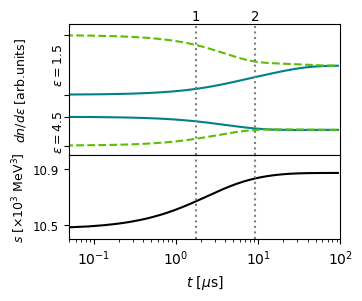

In [24]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, height_ratios=[0.61,0.39], figsize=(3.5, 2.8))
plt.subplots_adjust(hspace=0)

ax[0].plot(thermal['time'], ft_e[:,15], color=e_color, lw=1.5)
ax[0].plot(thermal['time'], ft_m[:,15], color=m_color, ls='--', lw=1.5)
ax[0].plot(thermal['time'], ft_e[:,45], color=e_color, lw=1.5)
ax[0].plot(thermal['time'], ft_m[:,45], color=m_color, ls='--', lw=1.5)

ax[0].set_ylim((-1*maxmin[0], 1.1*maxmin[-1]))
ax[0].set_yticks(maxmin)
ax[0].set_yticklabels(["","","",""])
ax[0].set_ylabel(r"$dn/d\epsilon$ [arb.units]", fontsize=9)


ax[0].text(0.045, (maxmin[2]+maxmin[3])/2, r"$\epsilon = 1.5$", fontsize=9, rotation='vertical', va='center', ha='right')
ax[0].text(0.045, (maxmin[0]+maxmin[1])/2, r"$\epsilon = 4.5$", fontsize=9, rotation='vertical', va='center', ha='right')

ax[1].plot(thermal['time'], s[1], c='k', lw=1.5)
ax[1].set_xscale('log')

ax[1].set_xlabel(r"$t~[\mu{\rm s}]$", fontsize=10)
ax[1].set_ylabel(r"$s~[\times 10^3~{\rm MeV^3}]$", fontsize=9)
ax[1].set_xticks([0.1, 1, 10, 100])
ax[1].set_yticks([10500, 10900])
ax[1].set_yticklabels([10.5, 10.9], fontsize=8.5)
ax[1].set_xlim(0.05, 100)
ax[1].set_ylim(10400,11000)

for i in range(1,3):
    for j in range(2):
        ax[j].axvline(thermal['time'][s_index[i]], c='0.50', ls=':')
    ax[0].text(thermal['time'][s_index[i]], 1.13*maxmin[-1], "{}".format(i), fontsize=9.5, ha='center')

fig.align_ylabels()
plt.savefig("PaperFigs/kinetic-sync.pdf", bbox_inches='tight')

Figure 7

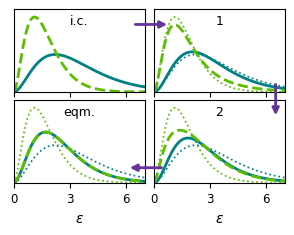

In [26]:
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(3.5, 2.25))
plt.subplots_adjust(hspace=0.1, wspace=0.1*2.5/3.5)

ax[0][0].set_xlim(0,7)
ax[0][0].set_ylim(0, max(np.max(fe[0,:]), np.max(fm[0,:]))*1.1)

ax[0][0].set_yticks([])

ax[0][1].plot(eps, ft_e[0,:], c=e_color, ls=':', lw=1.25)
ax[0][1].plot(eps, ft_m[0,:], c=m_color, ls=':', lw=1.25)
ax[1][0].plot(eps, ft_e[0,:], c=e_color, ls=':', lw=1.25)
ax[1][0].plot(eps, ft_m[0,:], c=m_color, ls=':', lw=1.25)
ax[1][1].plot(eps, ft_e[0,:], c=e_color, ls=':', lw=1.25)
ax[1][1].plot(eps, ft_m[0,:], c=m_color, ls=':', lw=1.25)

ax[0][0].plot(eps, ft_e[s_index[0],:], c=e_color, lw=2)
ax[0][0].plot(eps, ft_m[s_index[0],:], c=m_color, ls='--', lw=2)
ax[0][0].text(3.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "i.c.", fontsize=9, ha='center')

ax[0][1].plot(eps, ft_e[s_index[1]+5,:], c=e_color, lw=2)
ax[0][1].plot(eps, ft_m[s_index[1]+5,:], c=m_color, ls='--', lw=2)
ax[0][1].text(3.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "1", fontsize=9, ha='center')

ax[1][1].plot(eps, ft_e[s_index[2],:], c=e_color, lw=2)
ax[1][1].plot(eps, ft_m[s_index[2],:], c=m_color, ls='--', lw=2)
ax[1][1].text(3.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "2", fontsize=9, ha='center')

ax[1][0].plot(eps, ft_e[s_index[3],:], c=e_color, lw=2)
ax[1][0].plot(eps, ft_m[s_index[3],:], c=m_color, ls='--', lw=2)
ax[1][0].text(3.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "eqm.", fontsize=9, ha='center')

AB = pat.ConnectionPatch(
    xyA = (6.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (0.7, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[0][0], axesB = ax[0][1],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)
BC = pat.ConnectionPatch(
    xyA = (6.5, 0.1*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (6.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[0][1], axesB = ax[1][1],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)
CD = pat.ConnectionPatch(
    xyA = (0.4, 0.2*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (6.2, 0.2*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[1][1], axesB = ax[1][0],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)


fig.add_artist(AB)
fig.add_artist(BC)
fig.add_artist(CD)

for i in range(2):
    ax[1][i].set_xlabel(r"$\epsilon$", fontsize=10)
    ax[1][i].set_xticks([0,3,6])
    ax[1][i].set_xticklabels([0,3,6], fontsize=8.5)

plt.savefig("PaperFigs/kinetic-elapse.pdf", bbox_inches='tight')

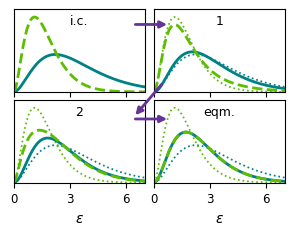

In [27]:
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(3.5, 2.25))
plt.subplots_adjust(hspace=0.1, wspace=0.1*2.5/3.5)

ax[0][0].set_xlim(0,7)
ax[0][0].set_ylim(0, max(np.max(fe[0,:]), np.max(fm[0,:]))*1.1)

ax[0][0].set_yticks([])

ax[0][1].plot(eps, ft_e[0,:], c=e_color, ls=':', lw=1.25)
ax[0][1].plot(eps, ft_m[0,:], c=m_color, ls=':', lw=1.25)
ax[1][0].plot(eps, ft_e[0,:], c=e_color, ls=':', lw=1.25)
ax[1][0].plot(eps, ft_m[0,:], c=m_color, ls=':', lw=1.25)
ax[1][1].plot(eps, ft_e[0,:], c=e_color, ls=':', lw=1.25)
ax[1][1].plot(eps, ft_m[0,:], c=m_color, ls=':', lw=1.25)

ax[0][0].plot(eps, ft_e[s_index[0],:], c=e_color, lw=2)
ax[0][0].plot(eps, ft_m[s_index[0],:], c=m_color, ls='--', lw=2)
ax[0][0].text(3.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "i.c.", fontsize=9, ha='center')

ax[0][1].plot(eps, ft_e[s_index[1]+5,:], c=e_color, lw=2)
ax[0][1].plot(eps, ft_m[s_index[1]+5,:], c=m_color, ls='--', lw=2)
ax[0][1].text(3.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "1", fontsize=9, ha='center')

ax[1][0].plot(eps, ft_e[s_index[2],:], c=e_color, lw=2)
ax[1][0].plot(eps, ft_m[s_index[2],:], c=m_color, ls='--', lw=2)
ax[1][0].text(3.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "2", fontsize=9, ha='center')

ax[1][1].plot(eps, ft_e[s_index[3],:], c=e_color, lw=2)
ax[1][1].plot(eps, ft_m[s_index[3],:], c=m_color, ls='--', lw=2)
ax[1][1].text(3.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:])), "eqm.", fontsize=9, ha='center')

AB = pat.ConnectionPatch(
    xyA = (6.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (0.7, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[0][0], axesB = ax[0][1],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)
BC = pat.ConnectionPatch(
    xyA = (0.4, 0.1*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (6.5, 0.9*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[0][1], axesB = ax[1][0],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)
CD = pat.ConnectionPatch(
    xyA = (6.5, 0.85*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    xyB = (0.7, 0.85*max(np.max(fe[0,:]), np.max(fm[0,:]))),
    coordsA="data", coordsB="data",
    axesA = ax[1][0], axesB = ax[1][1],
    arrowstyle = "-|>",
    color="rebeccapurple", lw=2)


fig.add_artist(AB)
fig.add_artist(BC)
fig.add_artist(CD)

for i in range(2):
    ax[1][i].set_xlabel(r"$\epsilon$", fontsize=10)
    ax[1][i].set_xticks([0,3,6])
    ax[1][i].set_xticklabels([0,3,6], fontsize=8.5)

plt.savefig("kinetic-elapseB.pdf", bbox_inches='tight')

Figure 8

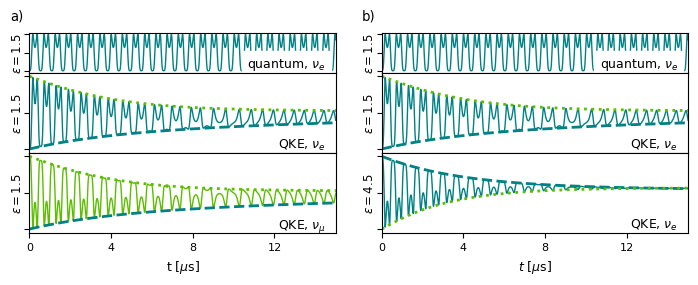

In [29]:
eps = QKE['eps']
fc_e = coherent['dnde'][pd.NU_E]
fq_e = QKE['dnde'][pd.NU_E]
fq_m = QKE['dnde'][pd.NU_MU]
ft_e = thermal['dnde'][pd.NU_E]
ft_m = thermal['dnde'][pd.NU_MU]

fig, axs = plt.subplots(nrows=3, ncols=2, sharex=True, figsize=(8.5,2.6), height_ratios=[0.2,0.4,0.4])
plt.subplots_adjust(hspace=0, wspace=0)

ax = axs[:,0]
ax[0].plot(coherent['time'], fc_e[:, index_plots[0]], c=e_color, label=r"quantum $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]), lw=1)

ax[1].plot(QKE['time'], fq_e[:, index_plots[0]], c=e_color, label=r"QKE $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]), lw=1)
ax[1].plot(thermal['time'], ft_e[:,index_plots[0]], c=e_color, ls="--", lw=2)
ax[1].plot(thermal['time'], ft_m[:,index_plots[0]], c=m_color, ls=":", lw=2)

ax[2].plot(QKE['time'], fq_m[:,index_plots[0]] , c=m_color, label=r"QKE $\nu_\mu,~\epsilon={:.2}$".format(eps[index_plots[0]]), lw=1)
ax[2].plot(thermal['time'], ft_e[:,index_plots[0]], c=e_color, ls="--", lw=2)
ax[2].plot(thermal['time'], ft_m[:,index_plots[0]], c=m_color, ls=":", lw=2)

#ax[2].set_xlim(0,min(np.max(coherent['time']), np.max(QKE['time'])))
ax[2].set_xlim(0, 15)
ax[2].set_xlabel(r"t [$\mu$s]", fontsize=9)

#ax[0].set_yticks([np.min(coherent[1][:,index_plots[0]]*eps[index_plots[0]]**2), np.max(coherent[1][:,index_plots[0]]*eps[index_plots[0]]**2)])
#ax[0].set_yticks([])

ytickmin = np.min(fc_e[:,index_plots[0]]) 
ytickmax = np.max(fc_e[:,index_plots[0]])


#ax[0].legend(loc='lower right')
#ax[1].legend(loc='lower right')
#ax[2].legend(loc='lower right')

ax[2].set_xticks([0, 4, 8, 12])
ax[2].set_xticklabels([0,4,8,12],fontsize=8)

ax[0].text(14.5, ytickmin + 0.03*(ytickmin+ytickmax), r"quantum, $\nu_e$", fontsize=9, ha='right', backgroundcolor='white')
ax[1].text(14.5, ytickmin + 0.005*(ytickmin+ytickmax), r"QKE, $\nu_e$", fontsize=9, ha='right')
ax[2].text(14.5, ytickmin + 0.005*(ytickmin+ytickmax), r"QKE, $\nu_\mu$", fontsize=9, ha='right')

for i in range(3):
    ax[i].set_ylabel(r"$\epsilon = 1.5$", fontsize=8.5, labelpad=-3)
    ax[i].set_yticks([ytickmin, 0.5*(ytickmin+ytickmax), ytickmax])
    ax[i].set_yticklabels(["","",""])

ax[0].text(-0.3, ytickmax*1.2, "a)", ha='right', fontsize=9.5)

ax = axs[:,1]
ax[0].plot(coherent['time'], fc_e[:,index_plots[0]], c=e_color, label=r"quantum $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]), lw=1)

for i in range(2):
    ax[i+1].plot(QKE['time'],fq_e[:,index_plots[i]], c=e_color, label=r"QKE $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[i]]), lw=1)
    ax[i+1].plot(thermal['time'], ft_e[:,index_plots[i]], ls="--", lw=2, c=e_color)
    ax[i+1].plot(thermal['time'], ft_m[:,index_plots[i]], ls=":", lw=2, c=m_color)

ax[0].set_xlim(0,15)
ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=9)
ax[2].set_xticks([0, 4, 8, 12])
ax[2].set_xticklabels([0,4,8,12],fontsize=8)

ymin = [0, 0]
ymax = [0, 0]
for i in range(3):
    ytickmin = np.min(coherent['f'][pd.NU_E][:,index_plots[i//2]]) * eps[index_plots[i//2]]**2/(2*np.pi**2)
    ytickmax = np.max(coherent['f'][pd.NU_E][:,index_plots[i//2]]) * eps[index_plots[i//2]]**2/(2*np.pi**2)

    ymin[i//2] = ytickmin
    ymax[i//2] = ytickmax

    ax[i].set_yticks([ytickmin, 0.5*(ytickmin+ytickmax), ytickmax])
    ax[i].set_yticklabels(["","",""])

    ax[i].set_ylabel(r"$\epsilon = {:.2}$".format(eps[index_plots[i//2]]), fontsize=8.5, labelpad=-3)

ax[0].text(-0.3, ymax[0]*1.2, "b)", ha='right', fontsize=9.5)

ax[0].text(14.5, ymin[0] + 0.03*(ymin[0]+ymax[0]), r"quantum, $\nu_e$", fontsize=9, ha='right', backgroundcolor='white')
ax[1].text(14.5, ymin[0] + 0.005*(ymin[0]+ymax[0]), r"QKE, $\nu_e$", fontsize=9, ha='right')
ax[2].text(14.5, ymin[1] + 0.005*(ymin[1]+ymax[1]), r"QKE, $\nu_e$", fontsize=9, ha='right')
fig.subplots_adjust(wspace=0.15)
plt.savefig("PaperFigs/QKE-sync.pdf", bbox_inches='tight')

Figure 9

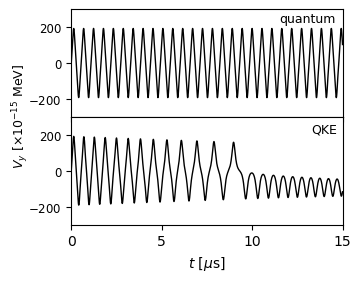

In [31]:
V_coherent = pd.V_mat(coherent)
V_QKE = pd.V_mat(QKE)

fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, sharey=True, figsize=(3.5,2.8))
plt.subplots_adjust(hspace=0)

ax[0].plot(coherent['time'], V_coherent[1,:]*1e15, c='k', lw=1)
ax[0].set_yticks([-200,0,200], [r"$-200$", 0, 200], fontsize=8.5)
ax[0].set_ylim(-300,300)
ax[0].text(11.5, 225, r"quantum", fontsize=9)
ax[0].set_xticks([0, 5, 10, 15], [0, 5, 10, 15], fontsize=8.5) 

ax[1].plot(QKE['time'], V_QKE[1,:]*1e15, c='k', lw=1)
ax[1].set_yticks([-200,0,200], [r"$-200$", 0, 200], fontsize=8.5)
ax[1].set_xlim(0,15)
ax[1].set_ylim(-300, 300)
ax[1].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=10)
ax[1].text(13.25,210, r"QKE", fontsize=9)

fig.supylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9, x=-0.05)

plt.savefig("PaperFigs/VyQuantumVsQKE.pdf", bbox_inches='tight')

Figure 10

In [33]:
P0, Px, Py, Pz = pd.make_P(coherent['rho'])
V_coherent = pd.V_mat(coherent)

t = coherent['time']
Vy = V_coherent[1,:]
dy = np.diff(Vy)

tlist = []
Vylist = []

for i in range(len(Vy)-2):
    
    if Vy[i]*Vy[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy[i]*dy[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

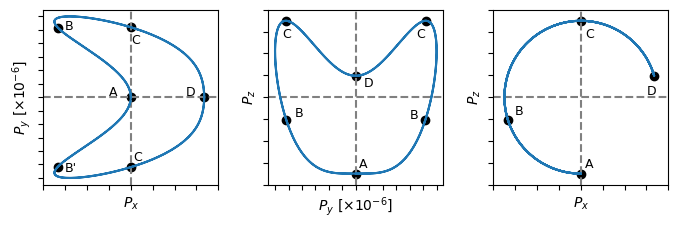

In [34]:
fig = plt.figure(figsize=(7,2.5))

array = ([0, 27, 48, 70, 90, 111])
xy1 = fig.add_axes([2/28, 1/10, 7/28, 7/10])
yz1 = fig.add_axes([11/28, 1/10, 7/28, 7/10])
xz1 = fig.add_axes([20/28, 1/10, 7/28, 7/10])

bloch = [xy1, yz1, xz1]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10
ticks = [-0.6 + 0.1 * i for i in range(13)]

xy1.plot(Px[t_index[0] : t_index[8],15], Py[t_index[0] : t_index[8],15]*1e6)
xy1.scatter(Px[0,15], Py[t_index[0],15]*1e6, c='k')
xy1.scatter(Px[27,15], Py[27,15]*1e6, c='k')
xy1.scatter(0, Py[48,15]*1e6, c='k')
xy1.scatter(Px[70,15], Py[70,15]*1e6, c='k')
xy1.scatter(0, -Py[48,15]*1e6, c='k')
xy1.scatter(Px[27,15], -Py[27,15]*1e6, c='k')
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy1.set_xticks(ticks)
xy1.set_yticks(ticks)
xy1.tick_params(labelbottom=False, labelleft=False)
xy1.set_xlim(-0.4,0.4)
xy1.set_ylim(-0.65,0.65)
xy1.text(-0.1,0.01, "A", fontsize=9)
xy1.text(-0.3,0.5, "B", fontsize=9)
xy1.text(0,0.4, "C", fontsize=9)
xy1.text(0.25,0.01, "D", fontsize=9)
xy1.text(0.01,-0.475, "C", fontsize=9)
xy1.text(-0.3,-0.55, "B'", fontsize=9)

yz1.plot(Py[t_index[0] : t_index[8],15]*1e6, Pz[t_index[0] : t_index[8],15])
yz1.scatter(Py[0,15]*1e6, Pz[0,15], c='k')
yz1.scatter(Py[27,15]*1e6, Pz[27,15], c='k')
yz1.scatter(Py[48,15]*1e6, Pz[48,15], c='k')
yz1.scatter(0, Pz[70,15], c='k')
yz1.scatter(-Py[48,15]*1e6, Pz[48,15], c='k')
yz1.scatter(-Py[27,15]*1e6, Pz[27,15], c='k')
yz1.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz1.set_yticks(ticks)
yz1.set_xticks(ticks)
yz1.tick_params(labelbottom=False, labelleft=False) 
yz1.set_xlim(-0.65,0.65)
yz1.set_ylim(-0.4,0.4)
yz1.text(0.02,-0.32, "A", fontsize=9)
yz1.text(0.4,-0.1, "B", fontsize=9)
yz1.text(0.45,0.27, "C", fontsize=9)
yz1.text(0.06,0.05, "D", fontsize=9)
yz1.text(-0.55,0.27, "C", fontsize=9)
yz1.text(-0.45,-0.09, "B", fontsize=9)

xz1.plot(Px[t_index[0] : t_index[8],15], Pz[t_index[0] : t_index[8],15])
xz1.scatter(Px[0,15], Pz[0,15], c='k')
xz1.scatter(Px[27,15], Pz[27,15], c='k')
xz1.scatter(0, Pz[48,15], c='k')
xz1.scatter(Px[70,15], Pz[70,15], c='k')
xz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz1.set_xticks(ticks)
xz1.set_yticks(ticks)
xz1.tick_params(labelbottom=False, labelleft=False) 
xz1.set_xlim(-0.4,0.4)
xz1.set_ylim(-0.4,0.4)
xz1.text(0.02,-0.32, "A", fontsize=9)
xz1.text(-0.3,-0.08, "B", fontsize=9)
xz1.text(0.02,0.27, "C", fontsize=9)
xz1.text(0.3,0.01, "D", fontsize=9)

plt.savefig("PaperFigs/CoherentBloch.pdf", bbox_inches='tight')

Figure 11

In [36]:
P0, Px, Py, Pz = pd.make_P(QKE['rho'])

t = QKE['time']
Vy = V_QKE[1,:]
dy = np.diff(Vy)

tlist = []
Vylist = []

for i in range(len(Vy)-2):
    
    if Vy[i]*Vy[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy[i]*dy[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

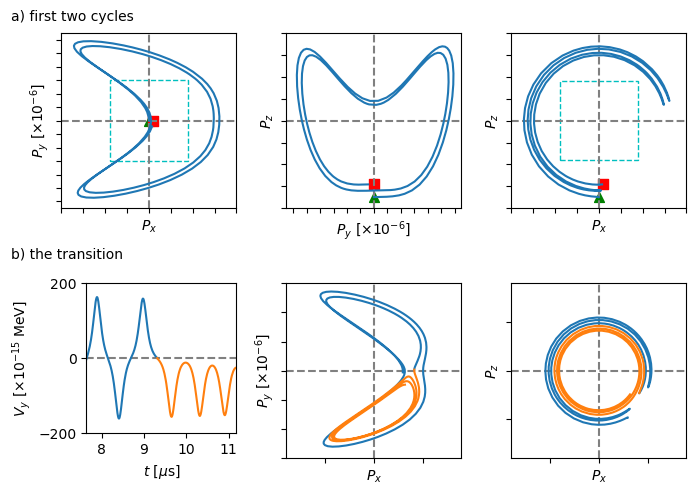

In [37]:

fig = plt.figure(figsize=(7,5))
subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0)

xy1 = subfigs[0].add_axes([2/28, 1/10, 7/28, 7/10])
yz1 = subfigs[0].add_axes([11/28, 1/10, 7/28, 7/10])
xz1 = subfigs[0].add_axes([20/28, 1/10, 7/28, 7/10])

xy2 = subfigs[1].add_axes([11/28, 1/10, 7/28, 7/10])
xz2 = subfigs[1].add_axes([20/28, 1/10, 7/28, 7/10])

xy2.set_box_aspect(1)
xz2.set_box_aspect(1)

V2 = subfigs[1].add_axes([3/28, 2/10, 6/28, 6/10])

V2.axhline(0, c='0.50', ls='--')

bloch = [xy1, yz1, xz1, xy2, xz2]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10
ticks = [-0.6 + 0.1 * i for i in range(13)]

#xy1.scatter(Px[t_index,15][1:9], Py[t_index,15][1:9]*1e6)
xy1.scatter(Px[t_index,15][0],Py[t_index,15][0]*1e6, marker='^', color='green', s=50, label=r"$t_0$")
xy1.scatter(Px[t_index,15][8],0, marker='s', color='red', s=50, label=r"$t_f$")
xy1.plot(Px[t_index[0] : t_index[8],15], Py[t_index[0] : t_index[8],15]*1e6)
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy1.set_xticks(ticks)
xy1.set_yticks(ticks)
xy1.tick_params(labelbottom=False, labelleft=False)
xy1.set_xlim(-0.4,0.4)
xy1.set_ylim(-0.65,0.65)
xy1.add_patch(plt.Rectangle((-.18, -.3), .36, .6, ls="--", fc="none", ec="c"))

#yz1.scatter(Py[t_index,15][1:9]*1e6, Pz[t_index,15][1:9])
yz1.scatter(Py[t_index,15][0]*1e6,Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
yz1.scatter(0,Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
yz1.plot(Py[t_index[0] : t_index[8],15]*1e6, Pz[t_index[0] : t_index[8],15])
yz1.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz1.set_yticks(ticks)
yz1.set_xticks(ticks)
yz1.tick_params(labelbottom=False, labelleft=False) 
yz1.set_xlim(-0.65,0.65)
yz1.set_ylim(-0.4,0.4)

#xz1.scatter(Pz[t_index,15][1:9],Px[t_index,15][1:9])
xz1.scatter(Px[t_index,15][0],Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
xz1.scatter(Px[t_index,15][8],Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
xz1.plot(Px[t_index[0] : t_index[8],15], Pz[t_index[0] : t_index[8],15])
xz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz1.set_xticks(ticks)
xz1.set_yticks(ticks)
xz1.tick_params(labelbottom=False, labelleft=False) 
xz1.set_xlim(-0.4,0.4)
xz1.set_ylim(-0.4,0.4)
xz1.add_patch(plt.Rectangle((-.18, -.18), .36, .36, ls="--", fc="none", ec="c", lw=1))


xy2.plot(Px[t_index[44]:t_index[50],15], Py[t_index[44]:t_index[50],15]*1e6)
xy2.plot(Px[t_index[50]:t_index[56],15], Py[t_index[50]:t_index[56],15]*1e6)
xy2.set_xticks(ticks)
xy2.set_yticks(ticks)
xy2.tick_params(labelbottom=False, labelleft=False) 
xy2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy2.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy2.set_xlim(-0.18,0.18)
xy2.set_ylim(-0.3,0.3)

xz2.plot(Px[t_index[44]:t_index[50],15], Pz[t_index[44]:t_index[50],15])
xz2.plot(Px[t_index[50]:t_index[56],15], Pz[t_index[50]:t_index[56],15])
xz2.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz2.set_xticks(ticks)
xz2.set_yticks(ticks)
xz2.tick_params(labelbottom=False, labelleft=False) 
xz2.set_xlim(-0.18,0.18)
xz2.set_ylim(-0.18,0.18)

V2.plot(t[t_index[44]:t_index[50]], Vy[Vy_index[44]:Vy_index[50]]*1e15)
V2.plot(t[t_index[50] :t_index[56]], Vy[Vy_index[50] :Vy_index[56]]*1e15)
V2.set_xlim(t[t_index[44]],t[t_index[56]])
V2.set_xticks([8,9,10,11])
V2.set_xticklabels([8,9,10,11])
V2.set_yticks([-200, 0, 200])
V2.set_xlabel(r"$t~[\mu{\rm s}]$", fontsize=label_fontsize)
V2.set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=label_fontsize)

subfigs[0].text(0,0.85,"a) first two cycles", fontsize=label_fontsize)
subfigs[1].text(0,0.9,"b) the transition", fontsize=label_fontsize)

plt.savefig("PaperFigs/Bloch.pdf", bbox_inches='tight')

Figure 12

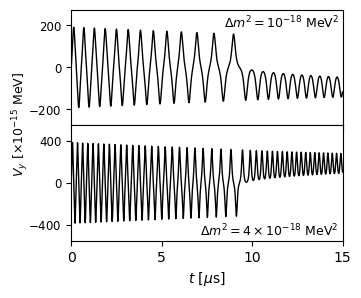

In [39]:
Vy_top = pd.V_mat(QKE)[1]
Vy_bot = pd.V_mat(dm4)[1]
t_top = QKE['time']
t_bot = dm4['time']

fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(3.5,3))
plt.subplots_adjust(hspace=0)

ax[0].plot(t_top, Vy_top*1e15, c='k', lw=1)
ax[0].set_yticks([-200,0,200], [r"$-200$", 0, 200], fontsize=8.5)
#ax[0].set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9)

ax[1].plot(t_bot, Vy_bot*1e15, c='k', lw=1)
ax[1].set_yticks([-400,0,400], [r"$-400$", 0, 400], fontsize=8.5)
ax[1].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=10)
#ax[1].set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9)

ax[0].set_xlim(0, 15)
ax[1].set_xlim(0,15)

ax[0].set_ylim(-275, 275)
ax[1].set_ylim(-275*2, 275*2)

ax[0].text(14.8, 190, r"$\Delta m^2 = 10^{-18}~\text{MeV}^2$", fontsize=9, ha='right')

ax[1].text(14.8, -190*2, r"$\Delta m^2 = 4 \times 10^{-18}~\text{MeV}^2$", fontsize=9, ha='right', va='top')
ax[0].set_xticks([0, 5, 10, 15], [0, 5, 10, 15], fontsize=8.5) 

#ax[1].set_xticks([0, 150, 300, 450], [0, 150, 300, 450], fontsize=8.5)

fig.supylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9, x=-0.05)
plt.savefig("PaperFigs/VySubplot.pdf", bbox_inches='tight')

Figure 13

In [41]:
P0, Px, Py, Pz = pd.make_P(dm4['rho'])

t = dm4['time']
dy_bot = np.diff(Vy_bot)


tlist = []
Vylist = []

for i in range(len(Vy_bot)-2):
    
    if Vy_bot[i]*Vy_bot[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy_bot[i]*dy_bot[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

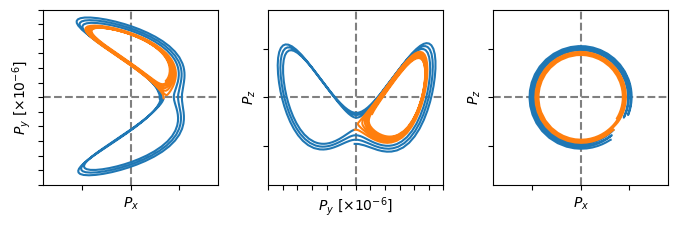

In [42]:
#Bloch Sphere evolution for 69 data (delta m^2 =1.196 yd² 4 x 10^-18,  all times


fig = plt.figure(figsize=(7,2.5))

array = ([0, 27, 48, 70, 90, 111])
xy = fig.add_axes([2/28, 1/10, 7/28, 7/10])
yz = fig.add_axes([11/28, 1/10, 7/28, 7/10])
xz = fig.add_axes([20/28, 1/10, 7/28, 7/10])


bloch = [xy, yz, xz]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

xy.plot(Px[t_index[88]:t_index[100],15], Py[t_index[88]:t_index[100],15]*1e6)
xy.plot(Px[t_index[100]:t_index[112],15], Py[t_index[100]:t_index[112],15]*1e6)
xy.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy.set_xticks(ticks)
xy.set_yticks(ticks)
xy.tick_params(labelbottom=False, labelleft=False) 
xy.set_xlim(-0.18,0.18)
xy.set_ylim(-0.6,0.6)

yz.plot(Py[t_index[88]:t_index[100],15]*1e6, Pz[t_index[88]:t_index[100],15])
yz.plot(Py[t_index[100]:t_index[112],15]*1e6, Pz[t_index[100]:t_index[112],15])
yz.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz.set_xticks(ticks)
yz.set_yticks(ticks)
yz.tick_params(labelbottom=False, labelleft=False) 
yz.set_xlim(-0.6,0.6)
yz.set_ylim(-0.18,0.18)

xz.plot(Px[t_index[92]:t_index[100],15], Pz[t_index[92]:t_index[100],15])
xz.plot(Px[t_index[100]:t_index[106],15], Pz[t_index[100]:t_index[106],15])
xz.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz.set_xticks(ticks)
xz.set_yticks(ticks)
xz.tick_params(labelbottom=False, labelleft=False) 
xz.set_xlim(-0.18,0.18)
xz.set_ylim(-0.18,0.18)

#xz.set_yticks([-0.2, 0, 0.2])
#xz.set_yticks([-0.2, 0, 0.2])
#xz.set_xlim(-0.2,0.2)
#xz.set_ylim(-0.2,0.2)

plt.savefig("PaperFigs/BlochFour.pdf", bbox_inches='tight')




Figure 14

In [44]:
eq_osc = [[10, 100], [1e-18*(10/32)**8, 1e-18*(100/32)**8]]

MHz1 = [[1, 100], [3.07e-16, 3.07e-20]]
MHz10 = [[2.5, 100], [49.12e-16, 3.07e-18]]
MHz01 = [[1, 100], [3.07e-18, 3.07e-22]]

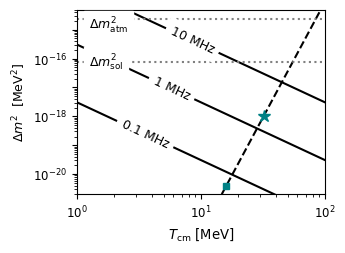

In [45]:
plt.figure(figsize=(3.2,2.4))

plt.loglog(MHz1[0], MHz1[1], c='k')
plt.text(4, 3.9e-18, "1 MHz", backgroundcolor='white', rotation=-25, fontsize=9)
plt.loglog(MHz01[0], MHz01[1], c='k')
plt.text(2.2, 0.8e-19, "0.1 MHz", backgroundcolor='white', rotation=-25, fontsize=9)
plt.loglog(MHz10[0], MHz10[1], c='k')
plt.text(5.5, 1.6e-16, "10 MHz", backgroundcolor='white', rotation=-25, fontsize=9)
plt.loglog(eq_osc[0], eq_osc[1], ls='--', c='k')
plt.loglog(32, 1.e-18, '*', ms=9, c=e_color)
plt.loglog(16, 3.90625e-21, 's', ms=5, c=e_color)

plt.axhline(7.41e-17, c='0.50', ls=':')
plt.text(1.25, 5.5e-17, r"$\Delta m^2_{\rm sol}$", backgroundcolor='white', fontsize=9)
plt.axhline(2.44e-15, c='0.50', ls=':')
plt.text(1.25, 1.e-15, r"$\Delta m^2_{\rm atm}$", backgroundcolor='white', fontsize=9)


plt.ylim(2e-21, 5e-15)
plt.xlim(1, 100)
plt.yticks([1e-20, 1e-19, 1e-18, 1e-17, 1e-16, 1e-15], [r"$10^{-20}$", "", r"$10^{-18}$", "", r"$10^{-16}$", ""], fontsize=8.5)
plt.xticks(fontsize=8.5)

plt.xlabel(r"$T_{\rm cm}$ [MeV]", fontsize=9.5)
plt.ylabel(r"$\Delta m^2~~[{\rm MeV}^2]$", fontsize=9)

plt.savefig("PaperFigs/freq_plot.pdf", bbox_inches='tight')

Figure 15

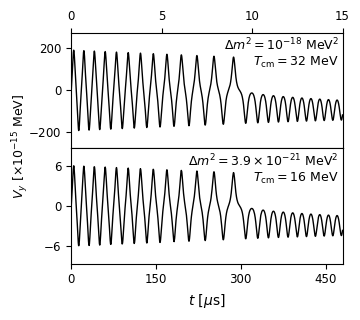

In [47]:
Vy_top = pd.V_mat(QKE)[1]
Vy_bot = pd.V_mat(match)[1]
t_top = QKE['time']
t_bot = match['time']

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(3.5,3))
plt.subplots_adjust(hspace=0)

ax[0].plot(t_top, Vy_top*1e15, c='k', lw=1)
ax[0].set_yticks([-200,0,200], [r"$-200$", 0, 200], fontsize=8.5)
#ax[0].set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9)
ax[0].set_xticks([0, 5, 10, 15], [0, 5, 10, 15], fontsize=8.5) 
ax[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

ax[1].plot(t_bot, Vy_bot*1e15, c='k', lw=1)
ax[1].set_yticks([-6,0,6])
ax[1].set_yticks([-6,0,6], [r"$-6$", 0, 6], fontsize=8.5)
ax[1].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=10)
#ax[1].set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9)

ax[0].set_xlim(0, 15)
ax[1].set_xlim(0,15*32)

ax[0].set_ylim(-275, 275)
ax[1].set_ylim(-275/32, 275/32)

ax[0].text(14.8, 190, r"$\Delta m^2 = 10^{-18}~\text{MeV}^2$", fontsize=9, ha='right')
ax[0].text(14.8, 115, r"$T_{\rm cm} = 32~\text{MeV}$", fontsize=9, ha='right')

ax[1].text(14.8*32, 190/32, r"$\Delta m^2 = 3.9 \times 10^{-21}~\text{MeV}^2$", fontsize=9, ha='right')
ax[1].text(14.8*32, 115/32, r"$T_{\rm cm} = 16~\text{MeV}$", fontsize=9, ha='right')

ax[1].set_xticks([0, 150, 300, 450], [0, 150, 300, 450], fontsize=8.5)

fig.supylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9, x=-0.05)
plt.savefig("PaperFigs/VyT16_match.pdf", bbox_inches='tight')